<h3 style = "color:green">Introduction

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">The rapid growth of electric vehicles (EVs) is reshaping the transportation industry worldwide. Understanding the factors that influence consumer adoption of EVs is essential for policymakers, manufacturers, and infrastructure providers. This dataset, containing 50,000 synthetic records, explores various demographic, behavioral, financial, transportation, and infrastructure-related characteristics that affect consumer decisions regarding electric vehicles. It captures relationships among commuting patterns, charging accessibility, environmental awareness, technology adoption, and EV-related concerns, providing valuable insights into the evolving electric mobility ecosystem.
</div>

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">
<ul>
<li>Note:</li>
<ul>
<ul>
<li>The word 'consumer' used in this project are people who currently own fuel/ICE vehicles and have NOT yet bought an EV. Each row represents a potential adopter — someone whose likelihood of switching to an EV is being studied.</li>
<li>The dataset is synthetically generated — so the 50,000 records don't represent real people. This project is focused on practicing EDA and further ML, not to  draw any  real-world conclusions from it.</li>
</ul>


<h3 style = "color:green">Objectives

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">
The primary objective of this Exploratory Data Analysis (EDA) is to identify patterns, trends, and relationships that influence electric vehicle adoption and usage. Specifically, the analysis aims to:
<ul>
<li>Understand the demographic and behavioral characteristics of potential EV consumers.</li>
<li>Explore the impact of commuting habits on EV adoption preferences.</li>
<li>Analyze the relationship between charging infrastructure availability and consumer willingness to switch to EVs.</li>
<li>Examine how environmental awareness influences EV-related decisions.</li>
<li>Investigate the role of technology adoption and innovation acceptance in EV ownership.</li>
<li>Identify key concerns and barriers that may discourage consumers from adopting electric vehicles.</li>
<li>Discover meaningful correlations and trends that can support future predictive modeling and consumer behavior research.</li>
</ul>


In [1]:
import pandas as pd
import polars as pl

from pandas import Series, DataFrame

import matplotlib.pyplot as plt
import seaborn as sns
import seaborn.objects as so

<h3 style ="color:green">1. Getting Ready with Dataset

In [2]:
data = pl.read_csv('/home/kartika/Datasets/global_ev_adoption_behavior_2026.csv')
data = data.to_pandas()

In [3]:
data.head()

,age,annual_income,education_level,city_type,daily_commute_km,weekly_travel_distance_km,current_vehicle_type,vehicle_age_years,fuel_expense_per_month,charging_station_accessibility,...,environmental_awareness_score,government_incentive_awareness,technology_affinity_score,range_anxiety_score,battery_replacement_concern,ev_knowledge_score,previous_ev_experience,ev_adoption_likelihood,monthly_energy_consumption_kwh,monthly_charging_cost
0,56,23019.0,High School,Suburban,39.8,205.7,Hatchback,6.1,317.1,3.9,...,8.3,6.4,5.2,4.6,3.5,6.9,0,High,199.8,28.5
1,46,26440.0,High School,Suburban,34.6,218.4,Sedan,4.4,290.0,4.5,...,7.8,10.0,5.7,5.5,7.4,6.9,1,High,139.8,22.9
2,46,57167.0,PhD,Suburban,30.5,177.7,Sedan,0.4,201.4,6.3,...,7.6,6.4,7.8,5.3,6.2,6.8,0,High,158.0,38.5
3,23,15841.0,Master,Suburban,44.6,325.9,SUV,0.0,407.3,5.2,...,6.2,5.6,5.1,7.9,5.7,7.2,0,Low,207.0,45.0
4,50,51571.0,Master,Urban,52.4,281.0,SUV,5.2,458.4,4.3,...,9.7,9.9,8.2,2.6,4.7,8.1,0,High,195.6,43.9


In [4]:
data.tail()

,age,annual_income,education_level,city_type,daily_commute_km,weekly_travel_distance_km,current_vehicle_type,vehicle_age_years,fuel_expense_per_month,charging_station_accessibility,...,environmental_awareness_score,government_incentive_awareness,technology_affinity_score,range_anxiety_score,battery_replacement_concern,ev_knowledge_score,previous_ev_experience,ev_adoption_likelihood,monthly_energy_consumption_kwh,monthly_charging_cost
49995,27,26296.0,Bachelor,Urban,37.4,211.4,Sedan,0.0,314.8,10.0,...,9.9,6.6,8.9,5.1,7.8,9.3,1,High,162.5,37.5
49996,39,35476.0,Master,Suburban,30.5,158.3,Sedan,2.8,278.5,7.5,...,8.7,6.0,9.4,3.8,2.0,8.8,0,High,129.6,11.9
49997,30,20862.0,Master,Suburban,37.5,295.2,Sedan,0.0,358.4,7.7,...,7.3,6.6,4.5,5.2,1.3,5.9,0,High,218.3,52.8
49998,68,14694.0,Bachelor,Rural,40.3,256.5,Sedan,6.0,306.1,2.7,...,8.3,3.8,6.6,4.7,5.4,9.3,0,High,216.0,50.3
49999,48,28828.0,Bachelor,Suburban,28.5,192.6,Sedan,2.5,227.5,8.9,...,4.6,7.2,6.1,6.5,4.1,5.8,0,Medium,136.0,13.7


In [5]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 23 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   age                             50000 non-null  int64  
 1   annual_income                   50000 non-null  float64
 2   education_level                 49500 non-null  object 
 3   city_type                       50000 non-null  object 
 4   daily_commute_km                50000 non-null  float64
 5   weekly_travel_distance_km       50000 non-null  float64
 6   current_vehicle_type            50000 non-null  object 
 7   vehicle_age_years               50000 non-null  float64
 8   fuel_expense_per_month          50000 non-null  float64
 9   charging_station_accessibility  49500 non-null  float64
 10  nearest_charging_station_km     50000 non-null  float64
 11  home_charging_available         50000 non-null  int64  
 12  electricity_cost_per_kwh        

In [6]:
data.isnull().sum()

age                                 0
annual_income                       0
education_level                   500
city_type                           0
daily_commute_km                    0
weekly_travel_distance_km           0
current_vehicle_type                0
vehicle_age_years                   0
fuel_expense_per_month              0
charging_station_accessibility    500
nearest_charging_station_km         0
home_charging_available             0
electricity_cost_per_kwh            0
environmental_awareness_score       0
government_incentive_awareness      0
technology_affinity_score           0
range_anxiety_score                 0
battery_replacement_concern         0
ev_knowledge_score                500
previous_ev_experience              0
ev_adoption_likelihood              0
monthly_energy_consumption_kwh      0
monthly_charging_cost               0
dtype: int64

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">The columns education_level, charging_station_accessibility and ev_knowledge_score contain null values. This will be handled during their respective analysis.</div>

In [7]:
data.duplicated().sum()

np.int64(0)

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">No duplicate values.

<div>

<h3 style = "color:green">2. Univariate Analysis

<h3 style = "color:green">2. Age Distribution

In [8]:
data['age'].describe()

count    50000.000000
mean        44.996080
std         14.110844
min         21.000000
25%         33.000000
50%         45.000000
75%         57.000000
max         69.000000
Name: age, dtype: float64

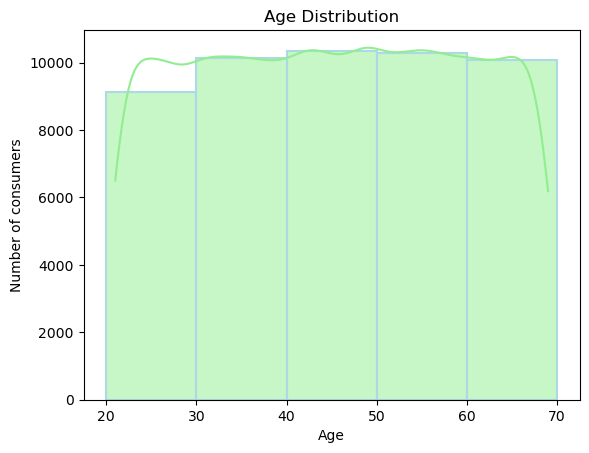

In [9]:
bins = [20, 30, 40, 50, 60, 70]
sns.histplot(data = data, x = 'age', bins = bins, kde = True, color = 'lightgreen', edgecolor = 'lightblue', linewidth = 1.5)


plt.title('Age Distribution')
plt.xlabel('Age')
plt.ylabel('Number of consumers')
plt.xticks(bins)
plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">75% of the consumer age between 21-57. The age is normally distributed, meaning most of the consumers age is around 44. Fewer people are very young or very old.

<div>

<h3 style = "color:green">2.2 Annual Income of Adopters

In [10]:
data['annual_income'].describe()

count     50000.000000
mean      44311.869380
std       26109.170784
min        5104.000000
25%       25617.750000
50%       37891.000000
75%       56051.250000
max      250000.000000
Name: annual_income, dtype: float64

In [11]:
data['annual_income'].skew()

np.float64(1.6507888986092154)

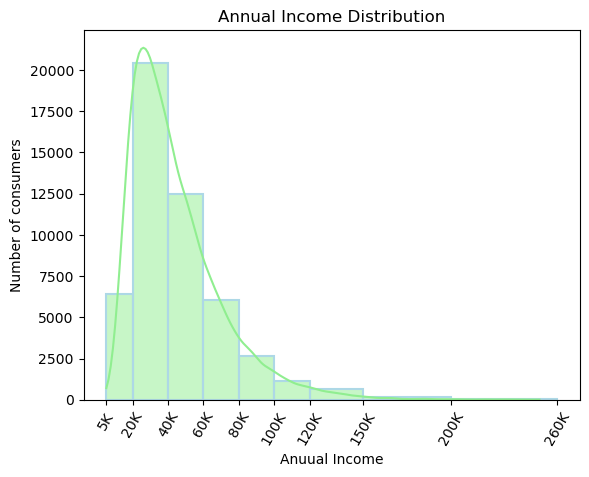

In [15]:
bins = [5000, 20000, 40000, 60000, 80000, 100000, 120000, 150000, 200000, 260000]
labels = ['5K', '20K', '40K', '60K', '80K', '100K', '120K', '150K', '200K', '260K']

sns.histplot(data = data, x = 'annual_income', bins = bins, kde = True, color = 'lightgreen', linewidth = 1.5, edgecolor = 'lightblue')

plt.title('Annual Income Distribution')
plt.xlabel('Anuual Income')
plt.ylabel('Number of consumers')
plt.xticks(bins, labels = labels, rotation = 60)
plt.show()

<div style = "background-color:lightblue; color:green; font-size:20px; text-align:justify">The annual income distribution is strongly positively skewed, implying majority of the consumer earns relatively low to moderate income, while a small percentage of consumer earns very high.</div>

<div>

<h3 style = "color:green">2.3 Education Level